In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re, numpy as np, scipy.stats as stats

# Set font size for plots
plt.rcParams.update({'font.size': 14})

In [34]:
dataFileName = "dbnLogs.csv"
targetNodes = ["DMZ_scanIP", "historian_scanVuln", "tomcatWebServer_bruteForce", "IED1_DERfailure"]
numSlices = 100

In [35]:
df = pd.read_csv(dataFileName)

In [36]:
# Remove all columns ending with >= _100
dropCols = [col for col in df.columns if (re.match("^(.)*_[0-9]+$", col) and int(col.split("_")[-1]) >= numSlices)]
df = df.drop(dropCols, axis=1)

In [37]:
distDict = {}
for nodeId in targetNodes:
    # Just take the columns that start with the target node name
    nodeCols = [col for col in df.columns if col.startswith(nodeId)]
    nodeData = df[nodeCols]
    firstCompletionData = []
    for i in range(0, len(nodeData)):
        firstCompletion = nodeData.iloc[i].value_counts()["N"] + 1
        firstCompletionData.append(firstCompletion if firstCompletion <= numSlices else np.nan)
    distDict[nodeId] = firstCompletionData
distDf = pd.DataFrame(distDict)  

# Make the columnt name a feature "nodeId" and the values "completion_time" for proper hue mapping
distDf_melted = distDf.melt(var_name='nodeId', value_name='completion_time')

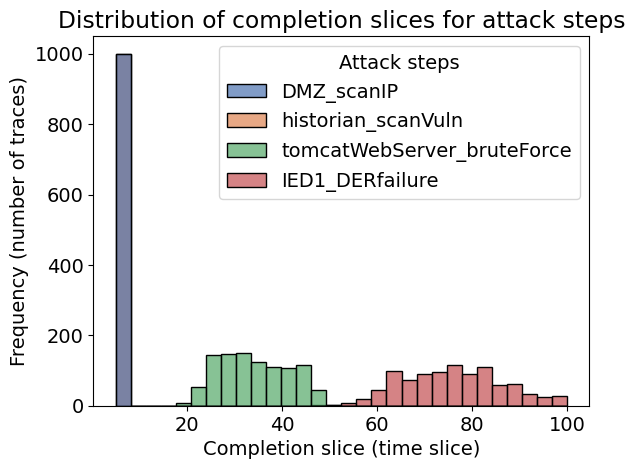

In [38]:
ax = sns.histplot(data=distDf_melted, x='completion_time', hue='nodeId', bins=30, 
             palette="deep", alpha=0.7, common_norm=False, 
             multiple="layer")
plt.xlabel("Completion slice (time slice)")
plt.ylabel("Frequency (number of traces)")
plt.title("Distribution of completion slices for attack steps")
ax.get_legend().set_title("Attack steps")
plt.savefig("plots/completion_slice_distribution.png")